In [2]:
import math
import numpy as np 
import matplotlib.pyplot as plt
from graphviz import Digraph

In [3]:
def f(x):
    return 3*x**2-4*x+5

In [4]:
f(3.0)

20.0

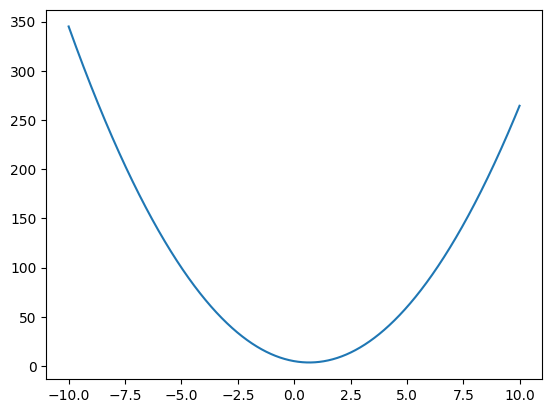

In [5]:
xs = np.arange(-10.0, 10.0, 0.01)
ys = f(xs)
# print(xs)
# print(ys)
plt.plot(xs, ys)

In [6]:
# Diffrentiating function

h = 0.0001
x = 7.5
(f(x+h)-f(x))/h

41.000299999609524

In [7]:
# Graphing functions

def trace(root):
# Builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data: %.4f | grad: %.04f}" %(n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    
    return dot

In [ ]:
# Making a Value wrapper class
class value:

    def __init__(self, data, _children = (), _op = (), label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None    #Empty function for backward pass

    def __repr__(self):
        return f"Value({self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, value) else value(other)
        o = value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += o.grad
            other.grad += o.grad
        o._backward = _backward

        return o
    
    def __sub__(self, other):
        other = other if isinstance(other, value) else value(other)
        return value(self.data - other.data, (self, other), '-')
    
    def __mul__(self, other):
        other = other if isinstance(other, value) else value(other)
        o = value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += o.grad * other.data
            other.grad += o.grad * self.data
        o._backward = _backward

        return o
    
    def __truediv__(self, other):
        other = other if isinstance(other, value) else value(other)
        o = value(self.data / other.data, (self, other), '/')
        def _backward():
            self.grad += o.grad / other.data
            other.grad += o.grad * (-self.data / other.data**2)
        o._backward = _backward
        return o

    def tanh(self):

        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        o = value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1-t**2)*o.grad
        o._backward = _backward
        
        return o
    
    def backward(self):
        # Topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __rmul__(self, other):
        return self * other
    
    def __radd__(self, other):
        return self + other
    
    def exp(self):
        x = self.data
        o = value(math.exp(x), (self,), label='exp')

        def _backward():
            self.grad += o.data * o.grad
        o._backward = _backward

        return o
    
    def pow(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        x = self.data
        o = value(x**other, (self,), f'pow{other}')

        def _backward():
            self.grad += other * x**(other-1) * o.grad
        o._backward = _backward

        return o
    

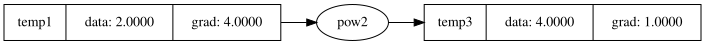

In [9]:
temp1 = value(2.0, label = 'temp1')
temp2 = value(3.0, label = 'temp2')
temp3 = temp1.pow(2); temp3.label = 'temp3'
temp3.backward()
draw_dot(temp3)
# Scalar with Wrapper object operations

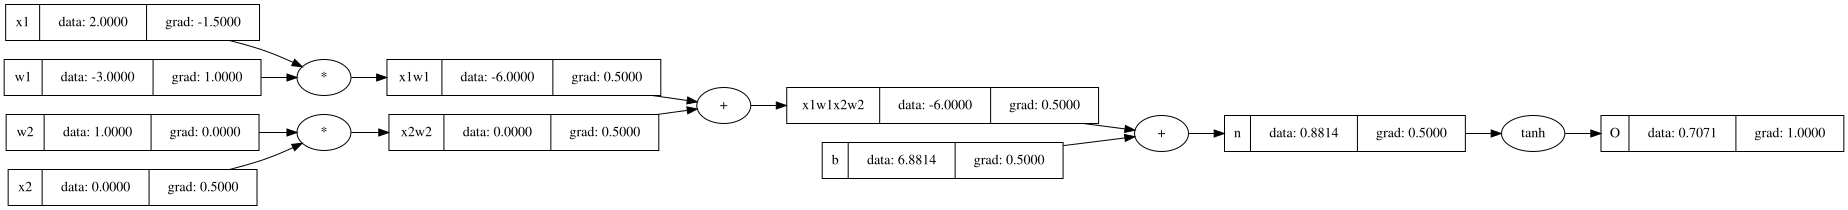

In [10]:
# Dummy neuron

x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')
b = value(6.8813735870195432, label='b')
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'O'

o.backward()

draw_dot(o)

we are applying local chain rule to the current node and the node ahead of it

eg: we know dL/de = -2.0

using chain rule for baackpropogation we get:

dL/da = dL/de * de/da

In [11]:
!jupyter nbconvert --clear-output --inplace your_notebook.ipynb

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.


<h2>Making neural networks using PyTorch</h2>

In [12]:
import torch

In [13]:
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(0.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(6.8813735870195432, requires_grad=True)
x1w1 = x1 * w1
x2w2 = x2 * w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b
o = n.tanh()
print(o)
o.backward()
print(x1.grad)
print(x1.item())

tensor(0.7071, grad_fn=<TanhBackward0>)
tensor(-1.5000)
2.0


In [14]:
class Neuron:
    
    def __init__(self, nin):
        self.w = [value(np.random.uniform(-1,1), label=f'w{i}') for i in range(nin)]
        self.b = value(0.0, label='b')
    
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

In [15]:
class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out if len(out) > 1 else out[0]
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

In [16]:
class MLP:
    # Multi Layer Perceptron
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

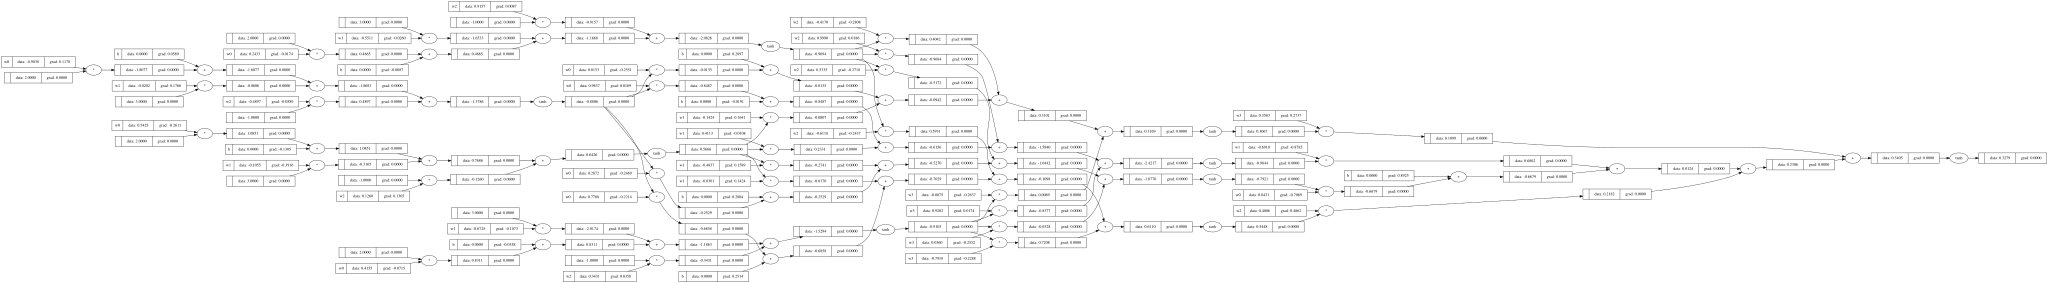

In [17]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)
n(x).backward()
draw_dot(n(x)) 

In [18]:
# Mini dataset

xs = [[-2.0, -1.0, 0.0],
      [-1.0, 0.0, 1.0],
      [0.0, 1.0, 2.0],
      [1.0, 2.0, 3.0]]

# What we want to predict
ys = [0.0, 1.0, 2.0, 3.0]

In [19]:
ypred = [n(x) for x in xs]
loss = sum((yout-ygt).pow(2) for yout, ygt in zip(ypred, ys))
loss

Value(20.586003755738687)

In [20]:
ypred = [n(x) for x in xs]
loss = sum((yout-ygt).pow(2) for yout, ygt in zip(ypred, ys))
loss

Value(20.586003755738687)

In [21]:
loss.backward()

In [22]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [23]:
for step in range(100):  # or any number of steps
    # Forward
    # ypred = [n(x) for x in xs]
    ypred = [n([value(xi) for xi in x]) for x in xs]
    loss = sum((yout-ygt).pow(2) for yout, ygt in zip(ypred, ys))

    # Zero gradients
    for p in n.parameters():
        p.grad = 0.0

    # Backward
    loss.backward()

    # Update
    for p in n.parameters():
        p.data += -0.01 * p.grad

    print(loss.data)  # To see loss changing

20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.64512285712192
20.6451228

In [24]:
def create_functions():
    functions = []
    for i in range(3):
        def func():
            return i
        functions.append(func)
    return functions
funcs = create_functions()
for f in funcs:
    print(f())

2
2
2
